In [1]:
!pip -q install pandas numpy matplotlib openpyxl statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
from google.colab import files
uploaded = files.upload()

# Replace with your uploaded file name if different
file = list(uploaded.keys())[0]
product = pd.read_excel(file, sheet_name='Product_List')
sales_month = pd.read_excel(file, sheet_name='Product _Sales_MonthWise')
inventory = pd.read_excel(file, sheet_name='Inventory_Data')

Saving BDM-DATASET.xlsx to BDM-DATASET.xlsx


In [3]:
print("PRODUCT DATA")
display(product.head())

print("MONTH-WISE SALES DATA")
display(sales_month.head())

print("INVENTORY DATA")
display(inventory.head())

PRODUCT DATA


,Product_ID,Product,Category,Packing Size,Adjusted MRP,Adjusted Cost Price,Selling Price
0,P001,AG ONE,Biostimulant,1 Litre,980,650,800
1,P002,SAAF,Fungicide,1 kg,820,490,600
2,P003,Coragen,Insecticide,60 ml,780,560,650
3,P004,Zintara 700,Fungicide,1 Litre,1540,1020,1250
4,P005,pendamil super,Herbicide,700 ml,380,230,250


MONTH-WISE SALES DATA


,Product_ID,Product_Name,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,P001,AG ONE,3,8,8,5,2,4,5,6,5,1,6,10
1,P002,SAAF,5,6,7,6,4,3,8,7,4,14,4,6
2,P003,Coragen,5,7,7,7,5,3,4,6,6,1,4,5
3,P004,Zintara 700,1,6,7,4,6,7,3,7,8,5,3,2
4,P005,pendamil super,3,8,11,7,2,4,3,7,6,3,3,4


INVENTORY DATA


,Product_ID,Product,Category,August-opening-stocks,August-sales,August-incoming,August-outgoing,August-closing-stocks,September-opening-stocks,September-sales,...,June-opening-stocks,June-sales,June-incoming,June-outgoing,June-closing-stocks,July-opening-stocks,July-sales,July-incoming,July-outgoing,July-closing-stocks
0,P001,AG ONE,Biostimulant,10,3,3,0,10,10,8,...,10,6,5,0,9,9,10,11,0,10
1,P002,SAAF,Fungicide,15,5,5,0,15,15,6,...,13,4,4,0,13,13,6,6,0,13
2,P003,Coragen,Insecticide,11,5,4,0,10,10,7,...,6,4,3,0,5,5,5,6,0,6
3,P004,Zintara 700,Fungicide,10,1,1,0,10,10,6,...,8,3,4,0,9,9,2,2,0,9
4,P005,pendamil super,Herbicide,8,3,3,0,8,8,8,...,6,3,3,0,6,6,4,4,0,6


In [4]:
sales_long = sales_month.melt(
    id_vars=['Product_ID','Product_Name'],
    var_name='Month',
    value_name='Units_Sold'
)

merged = sales_long.merge(product, left_on='Product_Name', right_on='Product', how='left')
merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')

merged['Profit_per_unit'] = merged['Selling Price'] - merged['Adjusted Cost Price']
merged['Revenue'] = merged['Units_Sold'] * merged['Selling Price']
merged['Profit'] = merged['Units_Sold'] * merged['Profit_per_unit']

print("MERGED DATA (This is our main analysis table)")
display(merged.head())

MERGED DATA (This is our main analysis table)


,Product_ID_x,Product_Name,Month,Units_Sold,Product_ID_y,Product,Category,Packing Size,Adjusted MRP,Adjusted Cost Price,Selling Price,Profit_per_unit,Revenue,Profit
0,P001,AG ONE,2024-08-01,3,P001,AG ONE,Biostimulant,1 Litre,980,650,800,150,2400,450
1,P002,SAAF,2024-08-01,5,P002,SAAF,Fungicide,1 kg,820,490,600,110,3000,550
2,P003,Coragen,2024-08-01,5,P003,Coragen,Insecticide,60 ml,780,560,650,90,3250,450
3,P004,Zintara 700,2024-08-01,1,P004,Zintara 700,Fungicide,1 Litre,1540,1020,1250,230,1250,230
4,P005,pendamil super,2024-08-01,3,P005,pendamil super,Herbicide,700 ml,380,230,250,20,750,60


#problem-3

we are dealing with only top 20% profit products

In [5]:
prod_summary = (
    merged.groupby(['Product_Name','Category'], as_index=False)
          .agg(Units_Sold=('Units_Sold','sum'),
               Revenue=('Revenue','sum'),
               Profit=('Profit','sum'))
)

prod_summary = prod_summary.sort_values('Profit', ascending=False)
display(prod_summary.head(8))

,Product_Name,Category,Units_Sold,Revenue,Profit
11,Gronior,Biostimulant,84,138600,30240
34,VN PLUS (Biostimulate),Biostimulant,65,78000,18200
0,ACT,Fungicide,60,96000,16800
28,V-CARE,Biostimulant,69,58650,13800
10,GUT,Biostimulant,76,72200,13680
8,DiAmmonia phosphate,Fertilizer,68,95200,13600
35,Zintara 700,Fungicide,59,73750,13570
24,SAKTHI,Biostimulant,63,81900,13230


In [6]:
cat_summary = (
    merged.groupby('Category', as_index=False)
          .agg(Revenue=('Revenue','sum'), Profit=('Profit','sum'))
          .sort_values('Profit', ascending=False)
)

display(cat_summary)

,Category,Revenue,Profit
0,Biostimulant,631100,133100
2,Fungicide,249650,43480
4,Insecticide,264550,42390
3,Herbicide,255650,36040
1,Fertilizer,267500,31440
5,Micronutrient,65050,9460
6,Seeds,63900,7810


In [7]:
pareto = prod_summary.copy()
pareto['Profit%'] = pareto['Profit'] / pareto['Profit'].sum()
pareto['Cum_Profit%'] = pareto['Profit%'].cumsum()

display(pareto)

,Product_Name,Category,Units_Sold,Revenue,Profit,Profit%,Cum_Profit%
11,Gronior,Biostimulant,84,138600,30240,0.10,0.10
34,VN PLUS (Biostimulate),Biostimulant,65,78000,18200,0.06,0.16
0,ACT,Fungicide,60,96000,16800,0.06,0.21
28,V-CARE,Biostimulant,69,58650,13800,0.05,0.26
10,GUT,Biostimulant,76,72200,13680,0.05,0.31
8,DiAmmonia phosphate,Fertilizer,68,95200,13600,0.04,0.35
35,Zintara 700,Fungicide,59,73750,13570,0.04,0.39
24,SAKTHI,Biostimulant,63,81900,13230,0.04,0.44
3,AMAZE Granules (Loose in Drum),Herbicide,63,72450,11340,0.04,0.48
5,BLOOM,Biostimulant,86,43000,10320,0.03,0.51


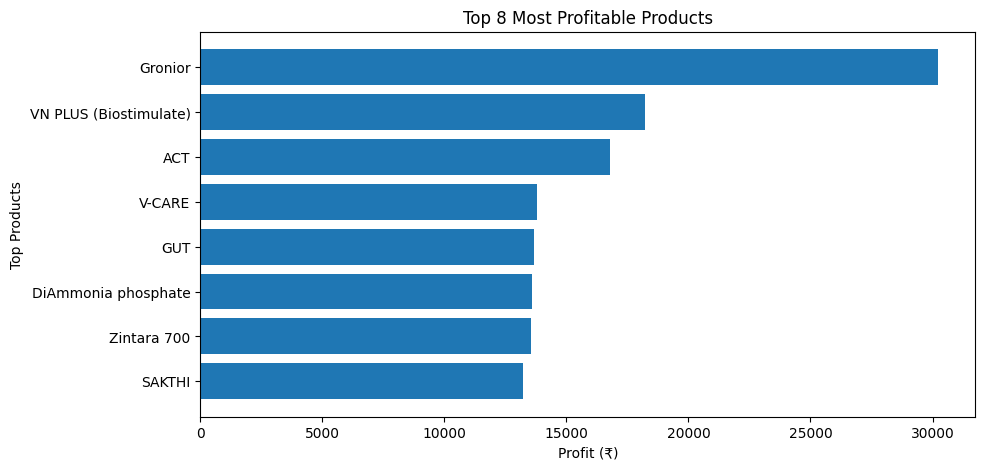

In [8]:
plt.figure(figsize=(10,5))
plt.barh(prod_summary['Product_Name'].head(8), prod_summary['Profit'].head(8))
plt.xlabel("Profit (₹)")
plt.ylabel("Top Products")
plt.title("Top 8 Most Profitable Products")
plt.gca().invert_yaxis()
plt.show()

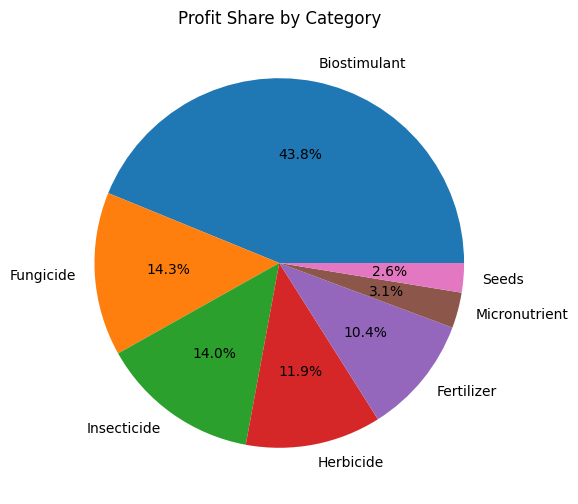

In [9]:
plt.figure(figsize=(6,6))
plt.pie(cat_summary['Profit'], labels=cat_summary['Category'], autopct='%1.1f%%')
plt.title("Profit Share by Category")
plt.show()

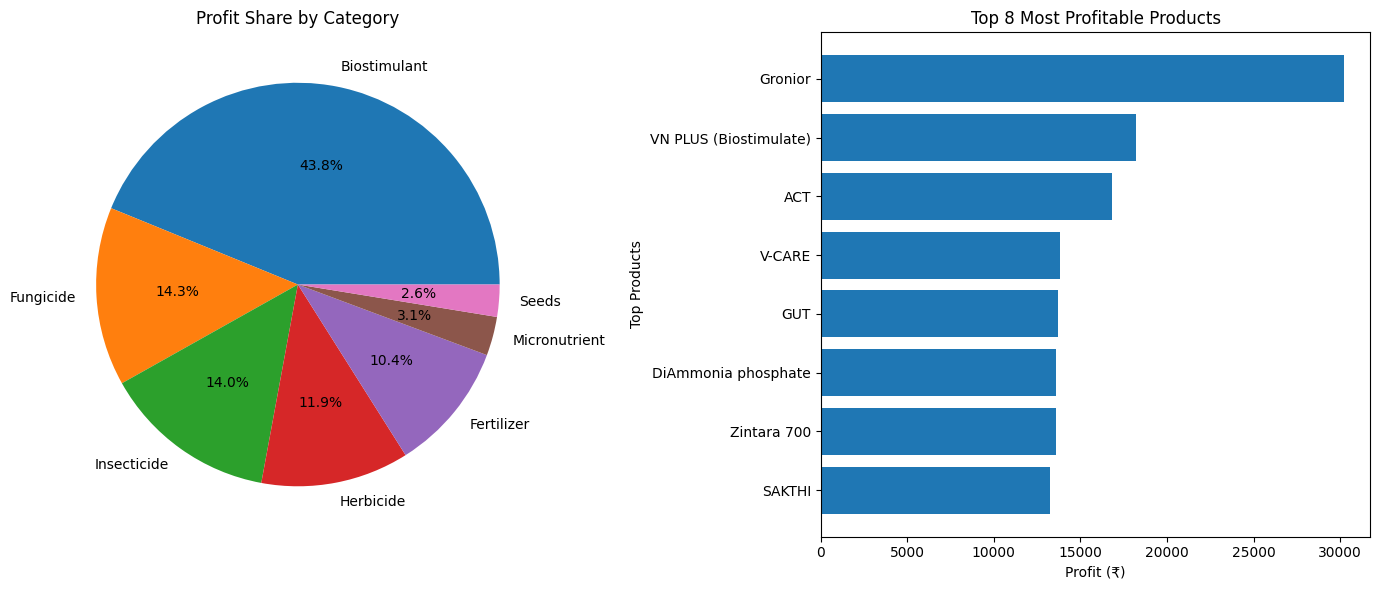

In [10]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Pie Chart (Profit Share by Category)
axes[0].pie(cat_summary['Profit'], labels=cat_summary['Category'], autopct='%1.1f%%')
axes[0].set_title("Profit Share by Category")

# Horizontal Bar Chart (Top 8 Most Profitable Products)
axes[1].barh(prod_summary['Product_Name'].head(8), prod_summary['Profit'].head(8))
axes[1].set_xlabel("Profit (₹)")
axes[1].set_ylabel("Top Products")
axes[1].set_title("Top 8 Most Profitable Products")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


#Scenario Modeling

In [11]:
# Base data
scenario_df = product.copy()
scenario_df['Profit_per_unit'] = scenario_df['Selling Price'] - scenario_df['Adjusted Cost Price']

print("Base Profit Summary:")
display(scenario_df[['Product', 'Selling Price', 'Adjusted Cost Price', 'Profit_per_unit']].head())

# Scenario 1: Selling Price +10%
scenario_df['SP_+10%'] = scenario_df['Selling Price'] * 1.10
scenario_df['Profit_+10%'] = scenario_df['SP_+10%'] - scenario_df['Adjusted Cost Price']

# Scenario 2: Cost Price -10%
scenario_df['CP_-10%'] = scenario_df['Adjusted Cost Price'] * 0.90
scenario_df['Profit_-10%'] = scenario_df['Selling Price'] - scenario_df['CP_-10%']

# Scenario 3: Selling +10% & Cost -10%
scenario_df['Combined_Profit'] = scenario_df['SP_+10%'] - scenario_df['CP_-10%']

# Display top results
print("Scenario Modeling Results (first 10 rows):")
display(scenario_df[['Product','Profit_per_unit','Profit_+10%','Profit_-10%','Combined_Profit']].head(10))

Base Profit Summary:


,Product,Selling Price,Adjusted Cost Price,Profit_per_unit
0,AG ONE,800,650,150
1,SAAF,600,490,110
2,Coragen,650,560,90
3,Zintara 700,1250,1020,230
4,pendamil super,250,230,20


Scenario Modeling Results (first 10 rows):


,Product,Profit_per_unit,Profit_+10%,Profit_-10%,Combined_Profit
0,AG ONE,150,230.00,215.00,295.00
1,SAAF,110,170.00,159.00,219.00
2,Coragen,90,155.00,146.00,211.00
3,Zintara 700,230,355.00,332.00,457.00
4,pendamil super,20,45.00,43.00,68.00
5,polygram,70,120.00,113.00,163.00
6,predator,130,210.00,197.00,277.00
7,Craze,90,130.00,121.00,161.00
8,shakti,130,190.00,177.00,237.00
9,Sangamithra seeds,110,200.00,189.00,279.00


##Scenario Modeling: Profit Improvement (Top 10 Products)

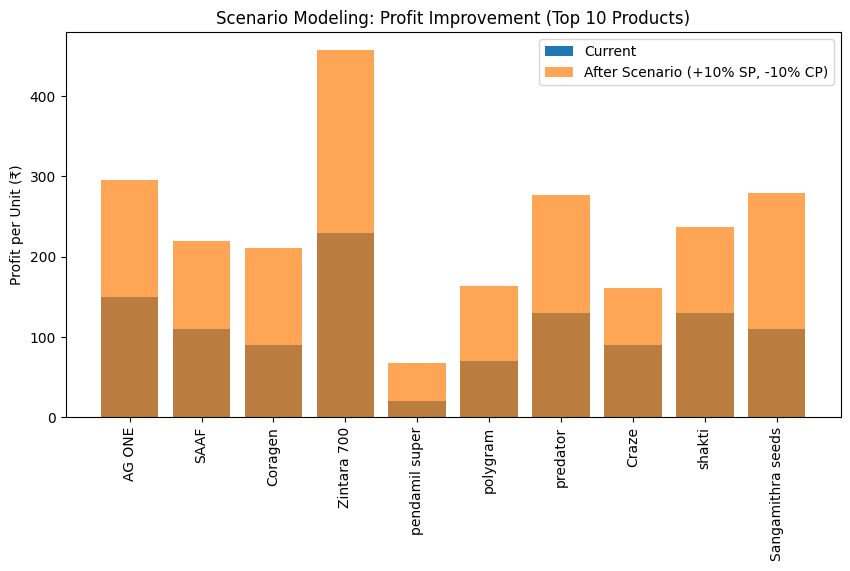

In [12]:
plt.figure(figsize=(10,5))
x = scenario_df['Product'][:10]
plt.bar(x, scenario_df['Profit_per_unit'][:10], label='Current')
plt.bar(x, scenario_df['Combined_Profit'][:10], alpha=0.7, label='After Scenario (+10% SP, -10% CP)')
plt.xticks(rotation=90)
plt.ylabel("Profit per Unit (₹)")
plt.title("Scenario Modeling: Profit Improvement (Top 10 Products)")
plt.legend()
plt.show()